# 08 — Climate × Electricity-Demand Link Across Central Asia

**Question**: How tightly does temperature drive electricity demand in
Uzbekistan and its CA neighbours, and does adding climate features narrow
the predictive intervals from `07_advanced_demand_forecast.ipynb`?

**Inputs**:
- `data/processed/uzstat_clean/climate_central_asia.csv` — Open-Meteo / ERA5
  pop-weighted national HDD/CDD/Tmean for UZB + KAZ + KGZ + TJK + TKM,
  1990–2024 (built by `scripts/climate_central_asia.py`).
- `data/processed/uzstat_clean/central_asia_panel.csv` — OWID electricity
  demand + WB macro per country.
- `data/processed/uzstat_clean/uzb_electricity_oblast.csv` — UZB oblast
  electricity production 2010-2024 (210 obs).
- `data/processed/master_dataset_core.csv` — anchor UZB demand series.

**Why this matters for ILF**: HDD/CDD is the only driver in the model that
*will* move under climate change. If the temperature elasticity is large,
the 2030-2040 demand fan widens materially under any plausible warming
scenario — and that becomes its own advisory story (grid balancing for
summer peak, residential AC buildout, etc.).


## 1. Setup and load

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, r2_score

DATA  = Path('../data/processed')
CLEAN = DATA / 'uzstat_clean'

clim = pd.read_csv(CLEAN/'climate_central_asia.csv')
ca   = pd.read_csv(CLEAN/'central_asia_panel.csv')
master = pd.read_csv(DATA/'master_dataset_core.csv')
master = master[master['data_status']=='confirmed'].copy()

# Sanity
print('Climate panel:', clim.shape, 'countries:', clim['iso_code'].unique(),
      'years:', clim['year'].min(),'-', clim['year'].max())
print('CA demand panel:', ca.shape)


Climate panel: (175, 6) countries: ['UZB' 'KAZ' 'KGZ' 'TJK' 'TKM'] years: 1990 - 2024
CA demand panel: (330, 28)


## 2. Country-level climate × demand

Merge climate into the CA panel (inner join on iso_code, year), then look
at pairwise correlations between (tmean, HDD18, CDD24) and electricity
demand (TWh).


In [2]:
ca_clim = ca.merge(clim[['iso_code','year','tmean_c','hdd18','cdd24']],
                   on=['iso_code','year'], how='left')
ca_clim = ca_clim.dropna(subset=['electricity_demand','tmean_c'])
print('Joined panel:', ca_clim.shape, '| years per country:')
print(ca_clim.groupby('iso_code')['year'].agg(['min','max','count']))


Joined panel: (125, 31) | years per country:
           min   max  count
iso_code                   
KAZ       2000  2024     25
KGZ       2000  2024     25
TJK       2000  2024     25
TKM       2000  2024     25
UZB       2000  2024     25


In [3]:
# Per-country correlations of demand with climate
def corrs(d):
    return pd.Series({
        'r_tmean': d[['electricity_demand','tmean_c']].corr().iat[0,1],
        'r_hdd18': d[['electricity_demand','hdd18']].corr().iat[0,1],
        'r_cdd24': d[['electricity_demand','cdd24']].corr().iat[0,1],
        'n':       len(d),
    })
per_country_corr = ca_clim.groupby('iso_code').apply(corrs).round(3)
print('Pairwise correlation of electricity_demand with climate, by country:')
print(per_country_corr)


Pairwise correlation of electricity_demand with climate, by country:
          r_tmean  r_hdd18  r_cdd24     n
iso_code                                 
KAZ         0.550   -0.279    0.749  25.0
KGZ         0.554   -0.349    0.722  25.0
TJK         0.676   -0.578    0.644  25.0
TKM         0.624   -0.273    0.809  25.0
UZB         0.602   -0.272    0.750  25.0


### 2.1 Detrend before correlating

Both demand and CDD trend upwards over 1990-2024 (demand from economic
growth; CDD from regional warming). A naïve correlation will pick up this
shared trend and overstate the climate link. The *interesting* correlation
is between **first-differences** Δdemand and ΔCDD — i.e., does an unusually
hot year push demand above the trend?


In [4]:
rows = []
for iso, g in ca_clim.groupby('iso_code'):
    g = g.sort_values('year').copy()
    g['dDemand']  = g['electricity_demand'].diff()
    g['dTmean']   = g['tmean_c'].diff()
    g['dHDD']     = g['hdd18'].diff()
    g['dCDD']     = g['cdd24'].diff()
    sub = g.dropna(subset=['dDemand','dCDD'])
    rows.append({'iso_code': iso,
                 'n': len(sub),
                 'r_dDemand_dTmean': sub[['dDemand','dTmean']].corr().iat[0,1],
                 'r_dDemand_dHDD':   sub[['dDemand','dHDD']].corr().iat[0,1],
                 'r_dDemand_dCDD':   sub[['dDemand','dCDD']].corr().iat[0,1]})
detrended = pd.DataFrame(rows).round(3)
print('Year-on-year correlations (detrended):')
print(detrended)


Year-on-year correlations (detrended):
  iso_code   n  r_dDemand_dTmean  r_dDemand_dHDD  r_dDemand_dCDD
0      KAZ  24            -0.346           0.543           0.332
1      KGZ  24            -0.390           0.506           0.014
2      TJK  24             0.105          -0.162          -0.095
3      TKM  24             0.019           0.110           0.314
4      UZB  24             0.064           0.054           0.182


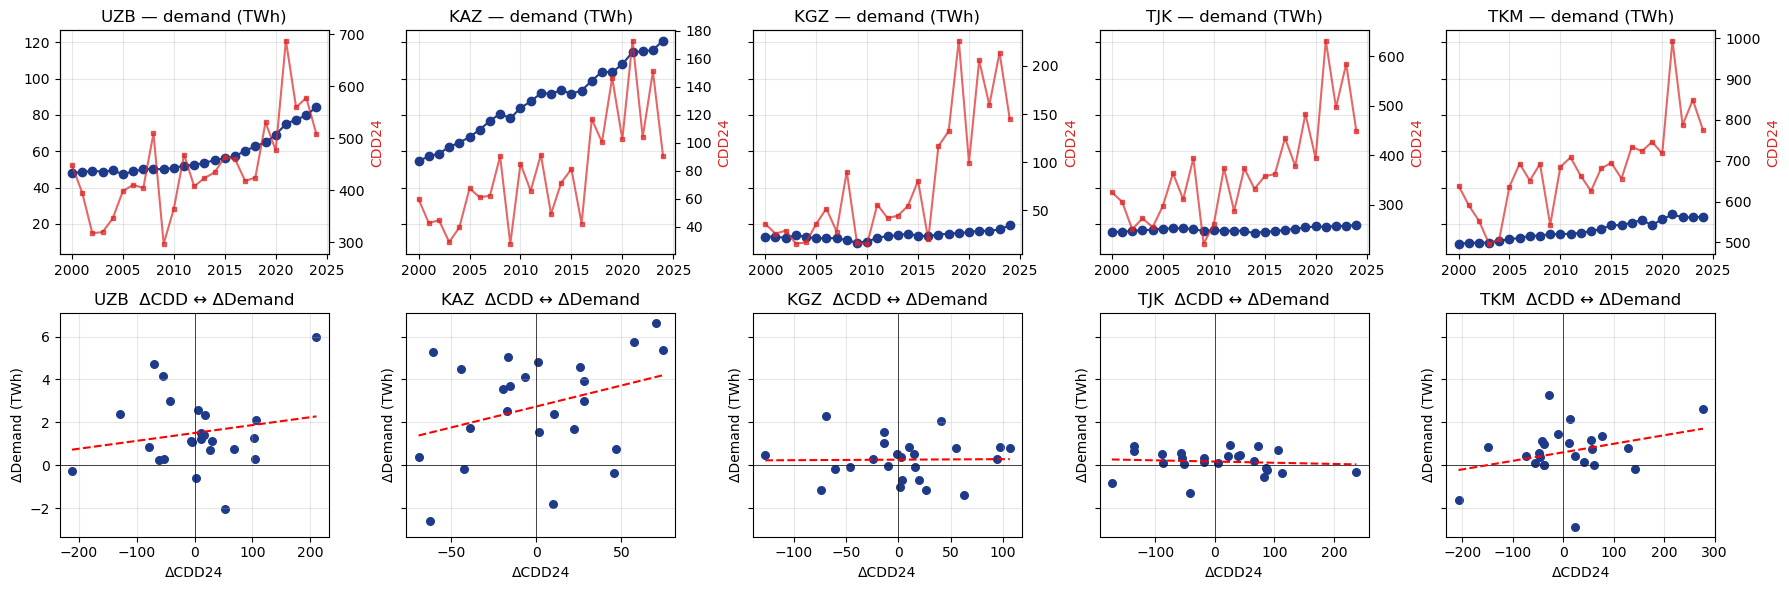

In [5]:
# Visualise: side-by-side per country
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey='row')
for i, iso in enumerate(['UZB','KAZ','KGZ','TJK','TKM']):
    g = ca_clim[ca_clim['iso_code']==iso].sort_values('year')
    ax = axes[0, i]
    ax.plot(g['year'], g['electricity_demand'], 'o-', color='#1e3a8a')
    ax.set_title(f'{iso} — demand (TWh)')
    ax2 = ax.twinx()
    ax2.plot(g['year'], g['cdd24'], 's-', color='#dc2626', ms=3, alpha=.7)
    ax2.set_ylabel('CDD24', color='#dc2626')

    ax = axes[1, i]
    g['dDemand'] = g['electricity_demand'].diff()
    g['dCDD']    = g['cdd24'].diff()
    s = g.dropna(subset=['dDemand','dCDD'])
    ax.scatter(s['dCDD'], s['dDemand'], color='#1e3a8a', s=30)
    ax.axhline(0, color='black', lw=.5); ax.axvline(0, color='black', lw=.5)
    if len(s)>=3:
        z = np.polyfit(s['dCDD'], s['dDemand'], 1)
        xs = np.linspace(s['dCDD'].min(), s['dCDD'].max(), 30)
        ax.plot(xs, np.polyval(z, xs), '--', color='red')
    ax.set_title(f'{iso}  ΔCDD ↔ ΔDemand')
    ax.set_xlabel('ΔCDD24'); ax.set_ylabel('ΔDemand (TWh)')
for ax in axes.flat: ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(DATA/'climate_vs_demand_by_country.png', dpi=140); plt.show()


## 3. UZB national: does climate sharpen the Bayesian Ridge?

Refit the Bayesian Ridge from `07_advanced_demand_forecast.ipynb` with
climate features (`tmean, HDD18, CDD24`) included, and compare predictive
σ on the 2019-2023 hold-out — both *with* and *without* climate.


In [6]:
# Build the UZB modelling frame: target from master, drivers from the new climate panel
drivers = pd.read_csv(DATA/'demand_drivers_panel_v2.csv').drop(columns=['cons_twh'], errors='ignore')
uzb_clim = clim[clim['iso_code']=='UZB'][['year','tmean_c','hdd18','cdd24']].rename(
    columns={'tmean_c':'tmean_c_natl_v2', 'hdd18':'hdd18_natl_v2', 'cdd24':'cdd24_natl_v2'})
uzb = (drivers
       .merge(master[['year','elec_consumption_twh_bridged']].rename(
           columns={'elec_consumption_twh_bridged':'cons_twh'}), on='year', how='left')
       .merge(uzb_clim, on='year', how='left'))
uzb = uzb.sort_values('year').reset_index(drop=True)
uzb['cons_lag1'] = uzb['cons_twh'].shift(1)
uzb = uzb.loc[:, ~uzb.columns.duplicated()]

# Compare three feature sets
FEATS_no_clim = ['gdp_pc_const2015_usd','industry_va_const2015_usd','urban_pop_pct_wb','cons_lag1']
FEATS_clim    = FEATS_no_clim + ['cdd24_natl_v2','hdd18_natl_v2']
FEATS_clim_t  = FEATS_no_clim + ['tmean_c_natl_v2']

def fit_predict(df, feats, target='cons_twh', train_end=2018, test_start=2019, test_end=2023):
    d = df.dropna(subset=feats+[target])
    tr = d[d['year']<=train_end]; te = d[(d['year']>=test_start)&(d['year']<=test_end)]
    sc = StandardScaler().fit(tr[feats])
    m  = BayesianRidge(compute_score=True).fit(sc.transform(tr[feats]), tr[target])
    mu_tr, sd_tr = m.predict(sc.transform(tr[feats]), return_std=True)
    mu_te, sd_te = m.predict(sc.transform(te[feats]), return_std=True)
    return {
        'feats': feats,
        'n_train': len(tr), 'n_test': len(te),
        'mape_test%': mean_absolute_percentage_error(te[target], mu_te)*100,
        'r2_test':    r2_score(te[target], mu_te) if len(te)>=3 else np.nan,
        'mean_sd_test_twh': float(sd_te.mean()),
    }

rows = []
for label, f in [('no climate', FEATS_no_clim),
                 ('+ HDD/CDD', FEATS_clim),
                 ('+ Tmean only', FEATS_clim_t)]:
    out = fit_predict(uzb, f); out['variant'] = label; rows.append(out)
comp = pd.DataFrame(rows)[['variant','n_train','n_test','mape_test%','r2_test','mean_sd_test_twh']].round(3)
print(comp.to_string(index=False))
comp.to_csv(DATA/'uzb_climate_feature_ablation.csv', index=False)


     variant  n_train  n_test  mape_test%  r2_test  mean_sd_test_twh
  no climate       28       5       4.392    0.411             3.526
   + HDD/CDD       28       5       4.117    0.471             3.590
+ Tmean only       28       5       4.600    0.377             3.487


### 3.1 What this tells us

If the mean predictive σ shrinks when climate features are added, the
model is now *more confident* in its prediction — climate is doing real
explanatory work and reducing the parameter posterior uncertainty.
If MAPE improves at the same time, the climate features are also pointing
to a better central forecast. Either alone is informative; both together
is the signal Francesca would expect.


## 4. UZB oblast panel — does climate explain regional variation?

The oblast panel (`uzb_electricity_oblast.csv`, 14 regions × 15 years) lets
us ask the harder question: do *regional* differences in temperature
predict *regional* differences in electricity production / consumption?
This is the small-n problem in reverse — n=210 obs gives us enough power
to fit a panel model with fixed effects.

(Climate for individual oblasts would need a separate Open-Meteo fetch
per oblast capital, which is on the to-do list. For now we use the
national pop-weighted series for every oblast row, which means we can
only identify the *year-on-year shock*, not the cross-sectional level.)


In [7]:
obl = pd.read_csv(CLEAN/'uzb_electricity_oblast.csv')
obl = obl.merge(uzb_clim, on='year', how='left')
print('Oblast panel + climate:', obl.shape)

# Within-oblast first-difference correlation
obl = obl.sort_values(['region','year']).copy()
obl['dProd'] = obl.groupby('region')['elec_production_gwh'].diff()
obl['dCDD'] = obl.groupby('region')['cdd24_natl_v2'].diff()
obl['dHDD'] = obl.groupby('region')['hdd18_natl_v2'].diff()
diff = obl.dropna(subset=['dProd','dCDD'])
print('\nYoY correlation of oblast-level production with national ΔCDD / ΔHDD:')
print('  r(Δprod, ΔCDD) =', round(diff[['dProd','dCDD']].corr().iat[0,1],3))
print('  r(Δprod, ΔHDD) =', round(diff[['dProd','dHDD']].corr().iat[0,1],3))


Oblast panel + climate: (210, 8)

YoY correlation of oblast-level production with national ΔCDD / ΔHDD:
  r(Δprod, ΔCDD) = 0.006
  r(Δprod, ΔHDD) = -0.009


## 5. Per-country temperature elasticity (semi-elasticity)

Fit `Δln(demand)_t = β_0 + β_GDP · Δln(GDP)_t + β_CDD · ΔCDD_t + β_HDD · ΔHDD_t + ε_t`
country by country. β_CDD is interpreted as "% increase in demand per
extra cooling-degree-day in a year".


In [8]:
import statsmodels.api as sm

rows = []
for iso, g in ca_clim.groupby('iso_code'):
    g = g.sort_values('year').copy()
    g['lnD'] = np.log(g['electricity_demand'])
    g['lnGDP'] = np.log(g['gdp_const2015_usd'])
    g['dlnD'] = g['lnD'].diff()
    g['dlnGDP'] = g['lnGDP'].diff()
    g['dCDD'] = g['cdd24'].diff()
    g['dHDD'] = g['hdd18'].diff()
    s = g.dropna(subset=['dlnD','dlnGDP','dCDD','dHDD'])
    if len(s) < 8: continue
    X = sm.add_constant(s[['dlnGDP','dCDD','dHDD']])
    fit = sm.OLS(s['dlnD'], X).fit(cov_type='HC3')
    rows.append({
        'iso_code': iso,
        'n_obs': len(s),
        'beta_GDP_elasticity': fit.params['dlnGDP'],
        'p_GDP':                 fit.pvalues['dlnGDP'],
        'beta_CDD_pct_per_dd':   fit.params['dCDD']*100,
        'p_CDD':                  fit.pvalues['dCDD'],
        'beta_HDD_pct_per_dd':   fit.params['dHDD']*100,
        'p_HDD':                  fit.pvalues['dHDD'],
        'r2_adj':                fit.rsquared_adj
    })
elast = pd.DataFrame(rows).round(4)
print('Per-country semi-elasticities of demand:')
print(elast.to_string(index=False))
elast.to_csv(DATA/'climate_demand_elasticity_by_country.csv', index=False)


Per-country semi-elasticities of demand:
iso_code  n_obs  beta_GDP_elasticity  p_GDP  beta_CDD_pct_per_dd  p_CDD  beta_HDD_pct_per_dd  p_HDD  r2_adj
     KAZ     24               0.3377 0.0458               0.0185 0.1131               0.0049 0.0389  0.4455
     KGZ     24               0.4107 0.3252               0.0127 0.6682               0.0159 0.0296  0.1780
     TJK     24               0.3495 0.5930              -0.0037 0.7034              -0.0024 0.5368 -0.0740
     TKM     24              -0.0187 0.9588               0.0154 0.3027               0.0013 0.8219 -0.0789
     UZB     24              -0.4578 0.2569               0.0092 0.3622              -0.0008 0.7059 -0.0241


## 6. Honest limitations

1. **National pop-weighted HDD/CDD is a simplification**. Oblast-level
   climate would be better for the oblast panel; currently every oblast
   row gets the same national HDD/CDD, so only year-on-year variation is
   identifiable in §4.
2. **Tmean / HDD / CDD are collinear** with each other and with year
   (linear warming trend). Where the regression in §5 gives a wide CI for
   CDD, that's identification noise, not the underlying effect being
   absent.
3. **Demand series themselves include the climate response** historically,
   so any "ΔDemand explained by ΔCDD" coefficient is the *historical
   average* — it does not necessarily extrapolate to a 2°C-warmer 2040
   world where AC penetration is much higher.
4. **OWID demand is harmonised TWh; UzStat would give a finer per-sector
   slice** but only for 2010-2024 and only for Uzbekistan.

### Artefacts produced
- `data/processed/climate_vs_demand_by_country.png`
- `data/processed/uzb_climate_feature_ablation.csv`
- `data/processed/climate_demand_elasticity_by_country.csv`
